In [1]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DS= df[df['job_title_short'] == 'Data Scientist'].copy()

In [8]:
df_DS['job_posted_month_no']= df_DS['job_posted_date'].dt.month

In [11]:
from pandas.api.types import CategoricalDtype
df_DS_explode= df_DS.explode('job_skills')
df_ds=df_DS_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

In [29]:
df_ds.loc['Total'] = df_ds.sum()
df_ds_pivot=df_ds[df_ds.loc['Total'].sort_values(ascending=False).index]
df_ds_pivot=df_ds_pivot.drop('Total', inplace=False)


<Axes: title={'center': 'Top 5 Skills for Data Scientist'}, xlabel='Month', ylabel='Count'>

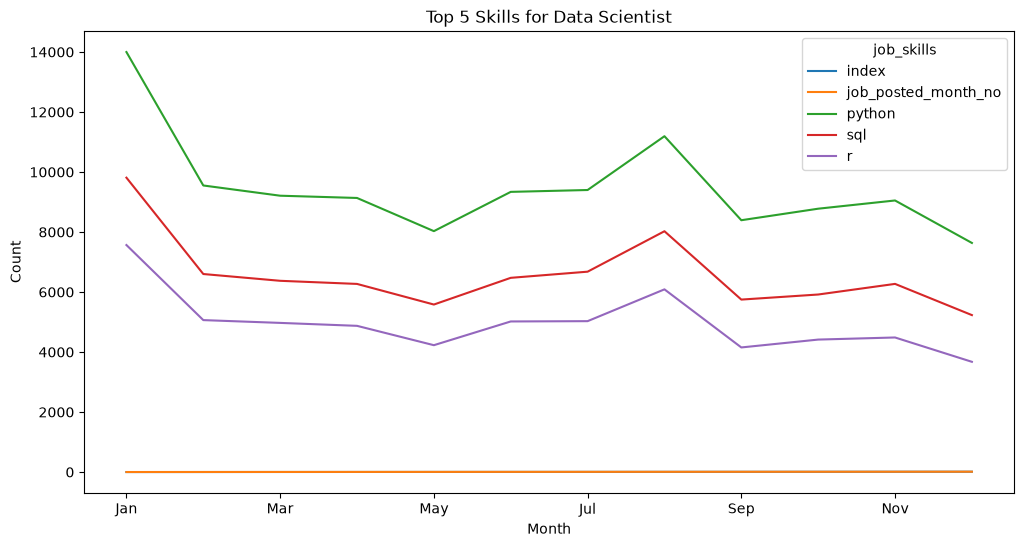

In [33]:
df_ds_pivot= df_ds_pivot.reset_index()
df_ds_pivot['job_posted_month']= df_ds_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x,format='%m').strftime('%b'))
df_ds_pivot= df_ds_pivot.set_index('job_posted_month')
df_ds_pivot.iloc[:, :5].plot(kind='line', figsize=(12, 6), title='Top 5 Skills for Data Scientist',ylabel='Count', xlabel='Month')